## Jax-power codes tests

In [1]:
import jax
from jax import config
import os, sys
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import h5py
import numpy as np
from mockfactory import Catalog
import matplotlib.pyplot as plt

sys.path.append('../../')
from cat_tools import get_catalog_fn, read_positions_weights, expand_randoms, get_proposal_mattrs, get_measurement_fn
from helper import REDSHIFT_BIN_LSS

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
tracer = 'QSO'
version = 'holi-v3'
# version = 'AbacusHF-v2'
domain = 'altmtl'
# ZSNAPS, ZRANGES = REDSHIFT_BIN_LSS[version]
ZRANGES = REDSHIFT_BIN_LSS

indz = 0
# znap = ZSNAPS[tracer][indz]
zrange = ZRANGES[tracer][indz]
(zmin, zmax) = zrange
data_args = {'version':version, 'domain':domain, 'tracer':tracer, 'zrange':zrange, 'mock_id': 0}
# data_args = {'version':version, 'domain':'altmtl', 'tracer':tracer, 'zsnap': znap, 'zrange':zrange, 'mock_id': 0}

In [4]:
get_data = lambda: read_positions_weights(**data_args, use_dv=False)
get_randoms = lambda: read_positions_weights(**data_args, random=True, nran=1)

In [26]:
import jax
from jaxpower import (ParticleField, FKPField, compute_fkp2_normalization, compute_fkp2_shotnoise, BinMesh2SpectrumPoles, get_mesh_attrs, 
                        compute_mesh2_spectrum, BinParticle2SpectrumPoles, BinParticle2CorrelationPoles, compute_particle2, compute_particle2_shotnoise)

data, randoms = get_data(), get_randoms()
mattrs = get_mesh_attrs(data[0], randoms[0], check=True, **get_proposal_mattrs('altmtl', tracer=tracer, meshsize=600))
data = ParticleField(*data, attrs=mattrs, exchange=True, backend='jax')
randoms = ParticleField(*randoms, attrs=mattrs, exchange=True, backend='jax')

[000658.85]  04-08 05:13  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_NGC_clustering.dat.h5.
[000658.85]  04-08 05:13  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_SGC_clustering.dat.h5.


[000666.16]  04-08 05:13  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_NGC_0_clustering.ran.h5.
[000666.16]  04-08 05:13  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_SGC_0_clustering.ran.h5.
[000666.17]  04-08 05:13  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.
[000666.18]  04-08 05:13  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_NGC_clustering.dat.h5.
[000666.18]  04-08 05:13  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_SGC_clustering.dat.h5.


In [29]:
fkp = FKPField(data, randoms)
ells=(0, 2, 4)
los='firstpoint'
cache=None
if cache is None: cache = {}
bin = cache.get('bin_mesh2_spectrum', None)
if bin is None: bin = BinMesh2SpectrumPoles(mattrs, edges={'step': 0.001}, ells=ells)
cache.setdefault('bin_mesh2_spectrum', bin)
norm = compute_fkp2_normalization(fkp, bin=bin, cellsize=20)
num_shotnoise = compute_fkp2_shotnoise(fkp, bin=bin)
mesh = fkp.paint(resampler='tsc', interlacing=3, compensate=True, out='real')
wsum_data1 = data.sum()
del data, randoms
jitted_compute_mesh2_spectrum = jax.jit(compute_mesh2_spectrum, static_argnames=['los'], donate_argnums=[0])
spectrum = jitted_compute_mesh2_spectrum(mesh, bin=bin, los=los).clone(norm=norm, num_shotnoise=num_shotnoise)
jax.block_until_ready(spectrum)
mattrs = {name: mattrs[name] for name in ['boxsize', 'boxcenter', 'meshsize']}
spectrum = spectrum.clone(attrs=dict(los=los, wsum_data1=wsum_data1, **mattrs))
jax.block_until_ready(spectrum)
result = spectrum

2026-04-08 05:16:53.567719: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.63GiB (rounded to 6048001536)requested by op 
2026-04-08 05:16:53.567832: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *********____***************************************________________________________________________
E0408 05:16:53.567847  759984 pjrt_stream_executor_client.cc:3077] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 6048001448 bytes. [tf-allocator-allocation-error='']


ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 6048001448 bytes.

In [19]:
import lsstypes as types
def load_mesh2_spectrum_poles(filename):
    result = types.read(filename)
    k = result.get(ells=0).coords('k')
    Pk = {ell: result.get(ells=ell).values() for ell in result.ells}
    return k, Pk

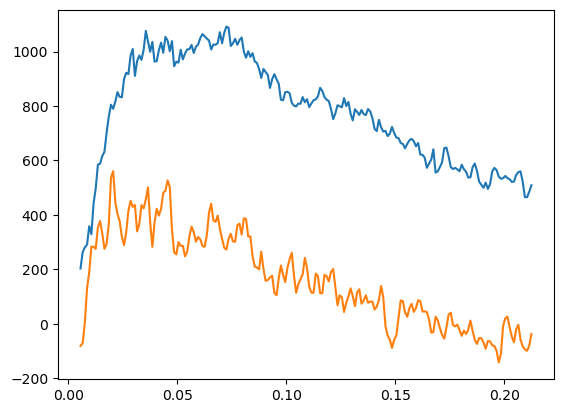

In [24]:
# fn = '/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/data_splits/blinded_data/data-dr2-v2/mesh2_spectrum_poles_LRG_z0.8-1.1_GCcomb_weight-default-FKP.h5'
# fn = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock1/mpspk/mesh2_spectrum_poles_LRG_z0.4-0.6_DR2_v2.0.h5'
fn = '/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock1/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_DR2_v2.0.h5'
spectrum = types.read(fn)

sl = slice(0, None, 1)
oklim = (0.005, 0.3)
result = spectrum.select(k=sl).select(k=oklim)
k = result.get(ells=0).coords('k')
pk = [result.get(ells=ell).values()['value'] for ell in result.ells]
plt.plot(k, k*pk[0], ls = '-')
plt.plot(k, k*pk[1], ls = '-')

## get_catalog_fn check 

In [ ]:
version = 'AbacusHF_DR2v2' # holi_v3, AbacusHF_DR2v2

cat_args = dict(version=version, tracer='LRG', zrange=(0.4, 0.6), mock_id=0, weight_type='WEIGHT', use_dv = False, domain='altmtl', random=False, nran=None)
fns = get_catalog_fn(**cat_args)
dats = Catalog.read(fns, group='LSS')

[000005.78]  04-07 07:25  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/AbacusHF_DR2v2/altmtl0/loa-v1/mock0/LSScats/LRG_NGC_clustering.dat.h5.
[000005.87]  04-07 07:25  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/AbacusHF_DR2v2/altmtl0/loa-v1/mock0/LSScats/LRG_SGC_clustering.dat.h5.


In [13]:
cat_args.update(random='parent', nran=1)
fns = get_catalog_fn(**cat_args)
pars = Catalog.read(fns, group='LSS')

cat_args.update(random=True)
fns = get_catalog_fn(**cat_args)
rans = Catalog.read(fns, group='LSS')

[000009.55]  04-07 07:25  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/dark_0_full_noveto.ran.h5.


[000009.65]  04-07 07:25  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/AbacusHF_DR2v2/altmtl0/loa-v1/mock0/LSScats/LRG_NGC_0_clustering.ran.h5.
[000009.65]  04-07 07:25  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/AbacusHF_DR2v2/altmtl0/loa-v1/mock0/LSScats/LRG_SGC_0_clustering.ran.h5.


In [ ]:
expand_rans = expand_randoms(rans, pars, dats)

In [41]:
from cat_tools import _make_z_evol_edges, _sample_cutsky_dv, CSPEED

cat_args = data_args
cat = Catalog.read(get_catalog_fn(**cat_args), group='LSS')

test_tracer = cat_args['tracer']
zmin, zmax = cat_args['zrange']
z = np.asarray(cat['Z'])
sel = np.isfinite(z) & (z >= zmin) & (z < zmax)
zsel = z[sel]

zedges = _make_z_evol_edges(zmin, zmax)
dv = _sample_cutsky_dv(test_tracer, zsel, zmin, zmax, use_dv='verr_nonparam', z_evol=True)
zshift = zsel + dv / CSPEED * (1. + zsel)

print('z_evol edges:', zedges.tolist())
print('N selected:', len(zsel))
print('dv global: mean={:.3f}, std={:.3f}, min={:.3f}, max={:.3f}'.format(dv.mean(), dv.std(), dv.min(), dv.max()))
print('z shifted range: ({:.4f}, {:.4f})'.format(zshift.min(), zshift.max()))

for i, (zlo, zhi) in enumerate(zip(zedges[:-1], zedges[1:])):
    if i == len(zedges) - 2:
        mask = (zsel >= zlo) & (zsel <= zhi)
    else:
        mask = (zsel >= zlo) & (zsel < zhi)
    if not np.any(mask):
        print(f'z-bin [{zlo:.1f}, {zhi:.1f}] : N=0')
        continue
    print(
        f'z-bin [{zlo:.1f}, {zhi:.1f}] : N={mask.sum()}, '
        f'dv mean={dv[mask].mean():.3f}, std={dv[mask].std():.3f}, '
        f'z range=({zsel[mask].min():.4f}, {zsel[mask].max():.4f})'
    )

[000140.43]  04-08 08:08  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_NGC_clustering.dat.h5.
[000140.44]  04-08 08:08  FileStack                    INFO     Reading /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/holi_v3/altmtl0/loa-v1/mock0/LSScats/QSO_SGC_clustering.dat.h5.
[000140.48]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/shengyu/repeats/DA2/loa-v1/verr_mode/CDF_verr_nonparam_QSO_z0.8-0.9.npz to generate redshift errors
[000140.51]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/shengyu/repeats/DA2/loa-v1/verr_mode/CDF_verr_nonparam_QSO_z0.9-1.0.npz to generate redshift errors


[000140.53]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/shengyu/repeats/DA2/loa-v1/verr_mode/CDF_verr_nonparam_QSO_z1.0-1.1.npz to generate redshift errors
[000140.55]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/shengyu/repeats/DA2/loa-v1/verr_mode/CDF_verr_nonparam_QSO_z1.1-1.2.npz to generate redshift errors
[000140.56]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/shengyu/repeats/DA2/loa-v1/verr_mode/CDF_verr_nonparam_QSO_z1.2-1.3.npz to generate redshift errors
[000140.58]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/shengyu/repeats/DA2/loa-v1/verr_mode/CDF_verr_nonparam_QSO_z1.3-1.4.npz to generate redshift errors
[000140.61]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/shengyu/repeats/DA2/loa-v1/verr_mode/CDF_verr_nonparam_QSO_z1.4-1.5.npz to generate redshift errors
[000140.63]  04-08 08:08  dv_tools                     INFO     use /pscratch/sd/s/sh